In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,mean_absolute_percentage_error
from scipy.optimize import curve_fit

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from sklearn.preprocessing import PolynomialFeatures
from itertools import combinations
from sklearn.feature_selection import f_regression

from sklearn.pipeline import make_pipeline

from sklearn.linear_model import Lasso




In [2]:

data=pd.read_excel("data - copie.xlsx")

In [3]:
data.describe()

,Laser Power (W),Laser Speed (mm/s),Hatch Spacing (µm),Layer thickness (µm),Surface roughness (um),Relative density (%),VED,LED,PED
count,136.000000,136.000000,136.000000,136.000000,136.000000,86.000000,136.000000,136.000000,136.000000
mean,187.919118,759.191176,95.970588,34.154412,9.952868,96.810000,89.880942,0.267921,2.880364
std,83.143846,247.760690,27.721178,12.642596,5.129858,3.959766,41.872701,0.140037,1.418130
min,60.000000,250.000000,50.000000,20.000000,2.600000,79.530000,17.833333,0.066667,0.937500
25%,150.000000,600.000000,80.000000,25.000000,6.285000,95.645000,60.934388,0.181364,1.860478
50%,160.000000,760.000000,90.000000,30.000000,9.580000,98.375000,81.620370,0.243725,2.492236
75%,225.000000,900.000000,115.000000,40.000000,11.540000,99.320000,108.482143,0.334091,3.612915
max,370.000000,1300.000000,200.000000,60.000000,31.310000,99.930000,227.243916,1.100000,9.166667


In [4]:
data.columns=['p','v','h','t','Ra','density','VED','LED','PED']
data.head(10)

,p,v,h,t,Ra,density,VED,LED,PED
0,150.0,400.0,115.0,25,5.20,99.63,130.434783,0.375000,3.260870
1,150.0,700.0,115.0,25,7.90,99.93,74.534161,0.214286,1.863354
2,150.0,1000.0,115.0,25,11.00,92.26,52.173913,0.150000,1.304348
3,180.0,400.0,115.0,25,5.00,99.91,156.521739,0.450000,3.913043
4,180.0,700.0,115.0,25,7.30,99.74,89.440994,0.257143,2.236025
5,180.0,1000.0,115.0,25,9.70,98.43,62.608696,0.180000,1.565217
6,200.0,400.0,115.0,25,4.60,99.53,173.913043,0.500000,4.347826
7,200.0,700.0,115.0,25,6.30,99.92,99.378882,0.285714,2.484472
8,200.0,1000.0,115.0,25,8.50,99.08,69.565217,0.200000,1.739130
9,180.4,821.6,72.2,20,11.57,98.31,152.057872,0.219572,3.041157


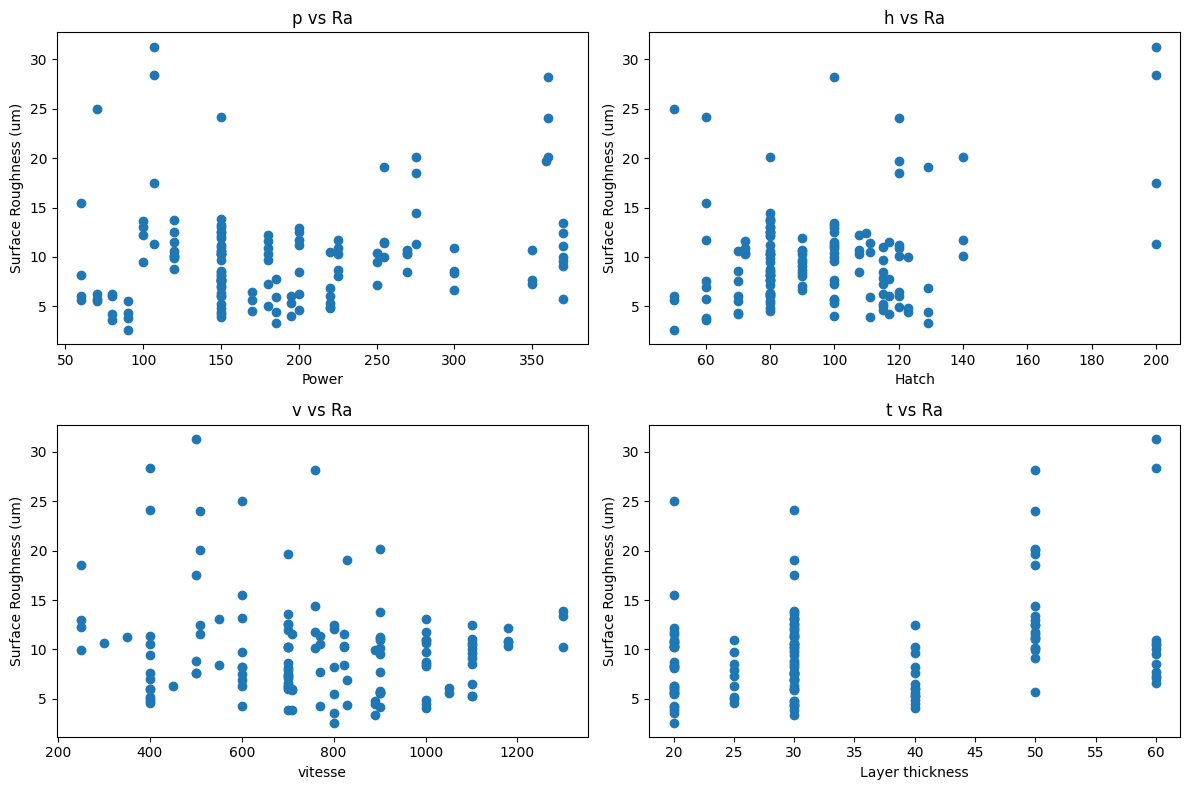

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0,0].scatter(data['p'], data['Ra'])
axs[0,0].set_xlabel('Power')
axs[0,0].set_ylabel('Surface Roughness (um)')
axs[0,0].set_title('p vs Ra')

axs[1,0].scatter(data['v'], data['Ra'])
axs[1,0].set_xlabel('vitesse')
axs[1,0].set_ylabel('Surface Roughness (um)')
axs[1,0].set_title('v vs Ra')

axs[0,1].scatter(data['h'], data['Ra'])
axs[0,1].set_xlabel('Hatch')
axs[0,1].set_ylabel('Surface Roughness (um)')
axs[0,1].set_title('h vs Ra')

axs[1,1].scatter(data['t'], data['Ra'])
axs[1,1].set_xlabel('Layer thickness')
axs[1,1].set_ylabel('Surface Roughness (um)')
axs[1,1].set_title('t vs Ra')
plt.tight_layout()

plt.show()


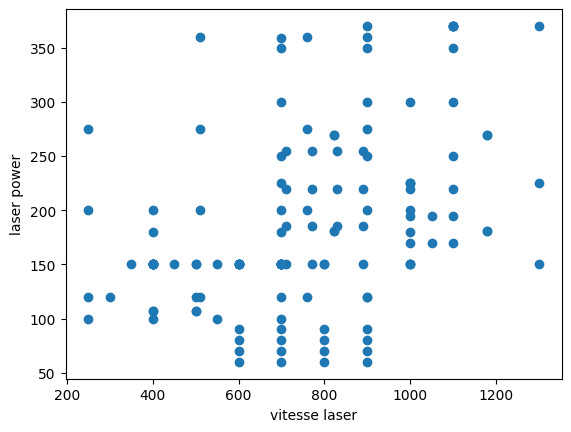

In [50]:
plt.scatter(data['v'],data['p'])
plt.xlabel('vitesse laser') 
plt.ylabel('laser power') 
plt.show()

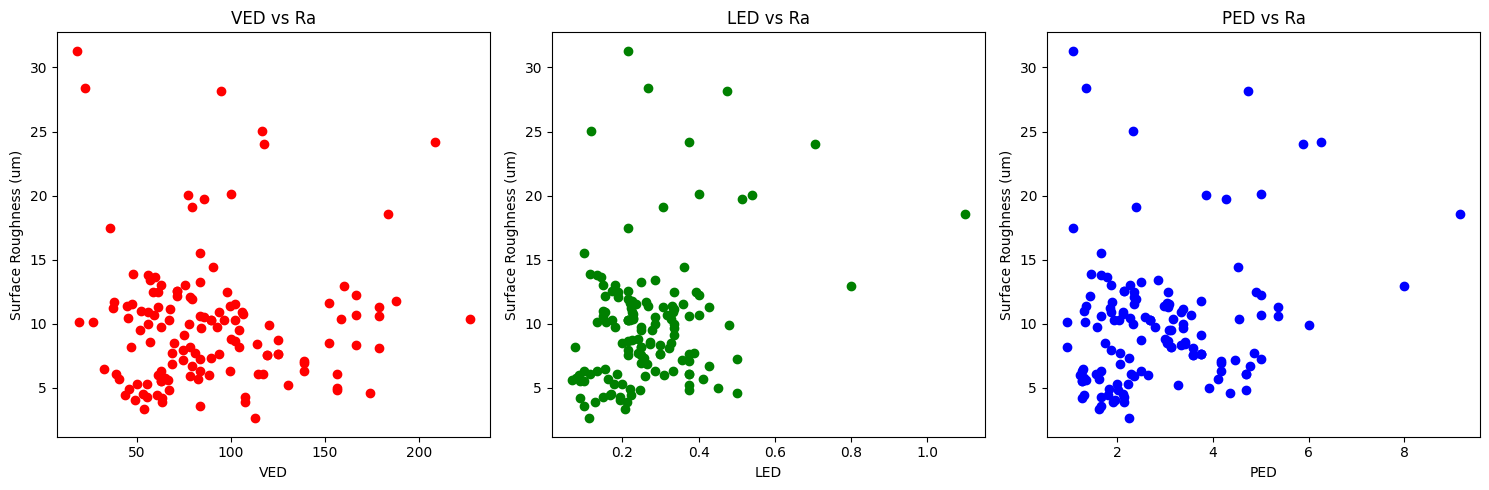

In [51]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].scatter(data['VED'], data['Ra'], color='r')
axs[0].set_xlabel('VED')
axs[0].set_ylabel('Surface Roughness (um)')
axs[0].set_title('VED vs Ra')

axs[1].scatter(data['LED'], data['Ra'], color='g')
axs[1].set_xlabel('LED')
axs[1].set_ylabel('Surface Roughness (um)')
axs[1].set_title('LED vs Ra')

axs[2].scatter(data['PED'], data['Ra'], color='b')
axs[2].set_xlabel('PED')
axs[2].set_ylabel('Surface Roughness (um)')
axs[2].set_title('PED vs Ra')

plt.tight_layout()

plt.show()

In [52]:
data2=data[data['density'].notnull()]
data2.describe()

,p,v,h,t,Ra,density,VED,LED,PED
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,154.523256,747.093023,85.174419,27.616279,8.996860,96.810000,100.856791,0.227029,2.699140
std,58.040020,251.381728,19.022310,7.305387,3.990742,3.959766,43.290918,0.102694,1.183697
min,60.000000,250.000000,50.000000,20.000000,2.600000,79.530000,32.196970,0.066667,0.937500
25%,120.000000,600.000000,72.200000,20.000000,6.035000,95.645000,65.277778,0.150772,1.797619
50%,150.000000,700.000000,80.000000,30.000000,8.390000,98.375000,93.171296,0.214286,2.338542
75%,180.400000,1000.000000,100.000000,30.000000,10.930000,99.320000,125.000000,0.282468,3.530844
max,359.000000,1300.000000,120.000000,50.000000,25.020000,99.930000,227.243916,0.512857,6.250000


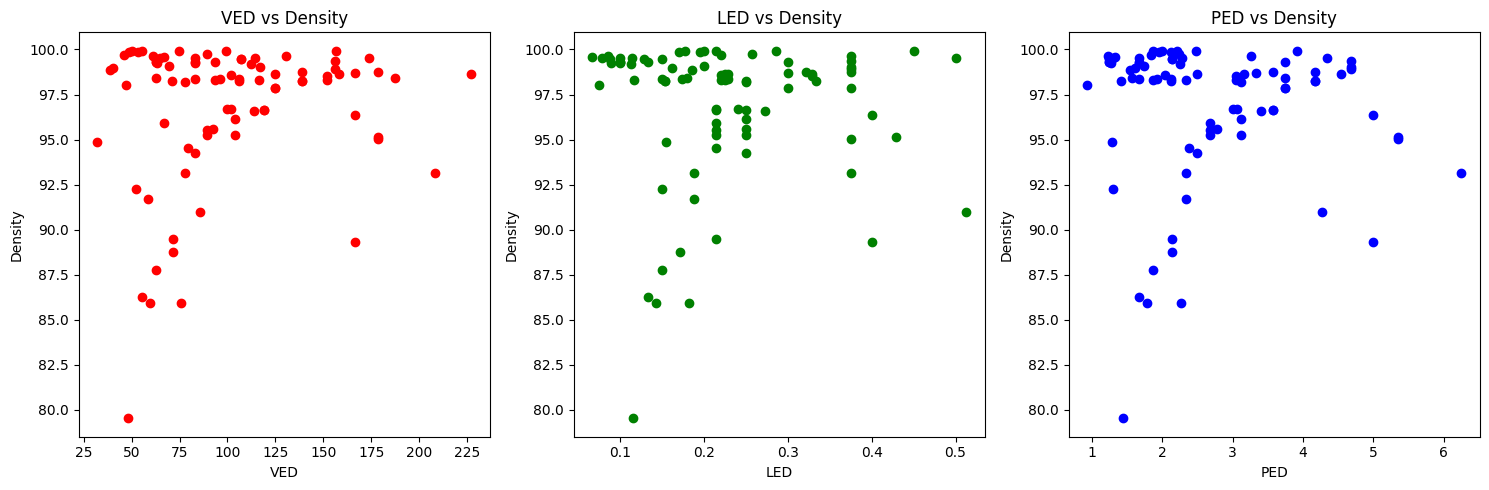

In [53]:
ig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].scatter(data2['VED'], data2['density'], color='r')
axs[0].set_xlabel('VED')
axs[0].set_ylabel('Density')
axs[0].set_title('VED vs Density')

axs[1].scatter(data2['LED'], data2['density'], color='g')
axs[1].set_xlabel('LED')
axs[1].set_ylabel('Density')
axs[1].set_title('LED vs Density')

axs[2].scatter(data2['PED'], data2['density'], color='b')
axs[2].set_xlabel('PED')
axs[2].set_ylabel('Density')
axs[2].set_title('PED vs Density')

plt.tight_layout()

plt.show()

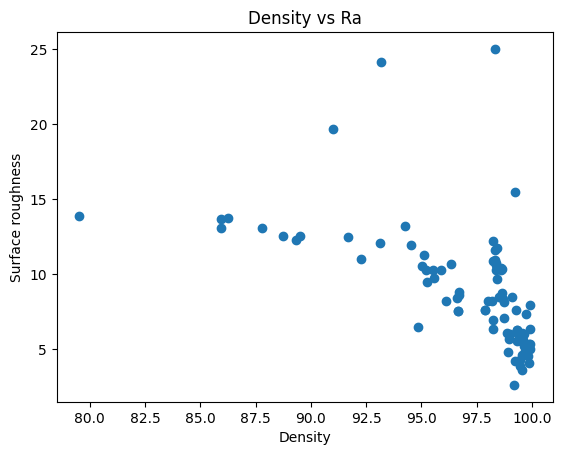

In [54]:
plt.scatter(data2['density'],data2['Ra'])
plt.xlabel('Density') 
plt.ylabel('Surface roughness') 
plt.title("Density vs Ra")
plt.show()

<Axes: >

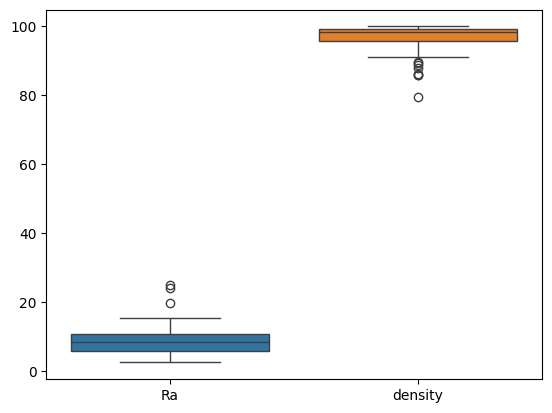

In [55]:
sns.boxplot(data=data2[['Ra', 'density']])

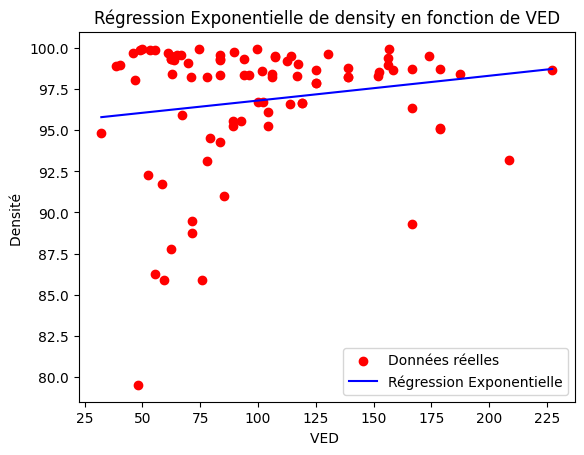

In [56]:
VED = data2['VED'].values
RD = data2['density'].values

def exp_model(x, a,b,):
    return b*np.exp(a*x)

params, covariance = curve_fit(exp_model, VED, RD, p0=[ 0.1,1,], maxfev=10000)

x_vals = np.linspace(min(VED), max(VED), 200)
y_vals = exp_model(x_vals, *params)

plt.scatter(VED, RD, color="red", label="Données réelles")
plt.plot(x_vals, y_vals, color="blue", label="Régression Exponentielle")
plt.xlabel("VED ")
plt.ylabel("Densité ")
plt.legend()
plt.title("Régression Exponentielle de density en fonction de VED")
plt.show()


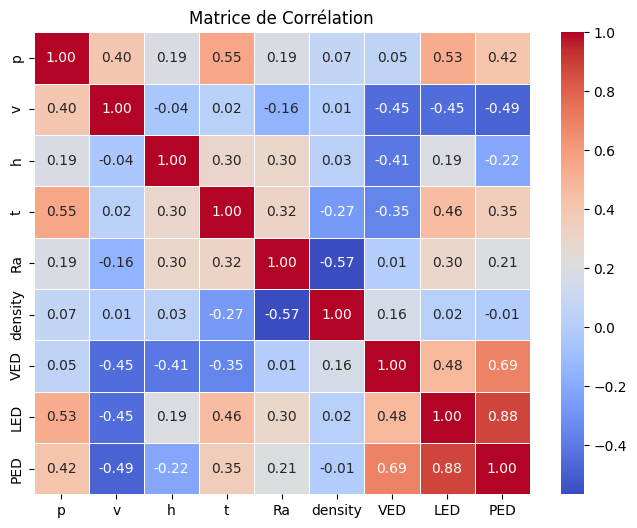

In [57]:

plt.figure(figsize=(8, 6))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Matrice de Corrélation")

plt.show()


Regression polynome:             3          2
-0.003603 x + 0.9341 x - 80.64 x + 2331


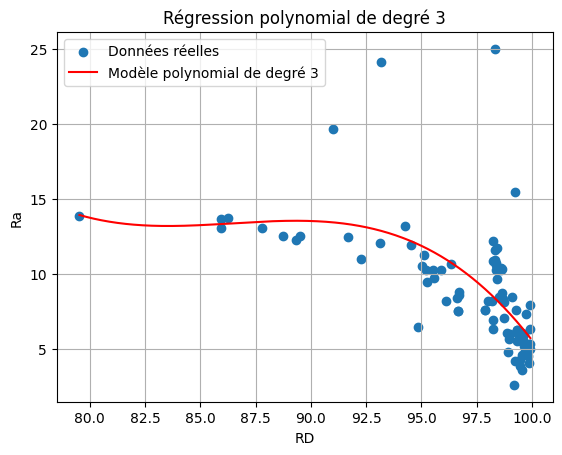

In [58]:


def polynomial_regression(y, x, n):
    
    coefficients = np.polyfit(x, y, n)
    
    return np.poly1d(coefficients)

x = data2['density'].values
y = data2['Ra'].values

f = polynomial_regression(y, x, 3)

print("Regression polynome: ", f)

x_values = np.linspace(np.min(x), np.max(x), 500) 

plt.scatter(x, y, label="Données réelles")

plt.plot(x_values, f(x_values), color='red', label="Modèle polynomial de degré 3")

plt.legend()
plt.xlabel('RD')
plt.ylabel('Ra')
plt.title('Régression polynomial de degré 3')
plt.grid(True)
plt.show()


Normalization && denormalization functions 

In [59]:


def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

def denormalize(data, original_data):
    return data * (np.max(original_data) - np.min(original_data)) + np.min(original_data)


BOX-COX functions

In [5]:
def box_cox_fun(data):

    lambda_val = 0.5

    data, _ = boxcox(data + 1e-5)
    return data,lambda_val
def inverse_box_cox(data, lambda_val=0.5):
    if lambda_val == 0:
        return np.exp(data)
    else:
        return (data * lambda_val + 1) ** (1 / lambda_val) - 1e-5

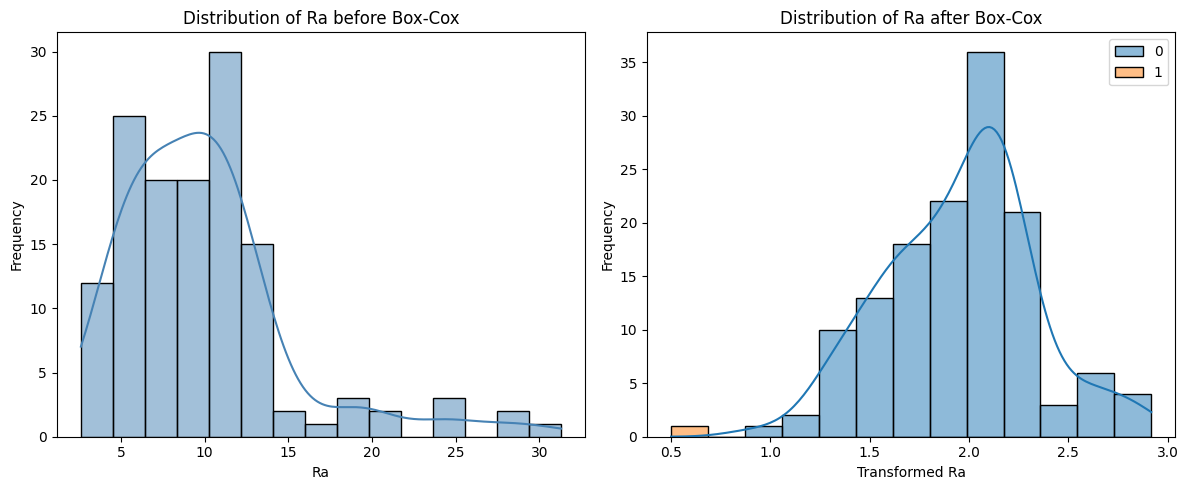

In [7]:


Ra = data['Ra'].values

Ra_transformed = box_cox_fun(Ra)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(Ra, kde=True, color='steelblue')
plt.title('Distribution of Ra before Box-Cox')
plt.xlabel('Ra')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(Ra_transformed, kde=True, color='seagreen')
plt.title('Distribution of Ra after Box-Cox')
plt.xlabel('Transformed Ra')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


Exponential parameters: [-819.64445401   14.39786921  834.45773559  -14.64887335   10.35935754]
RMSE: 4.703170935793973
MAE: 3.5235759412368672
MAPE: 43.28438855124943


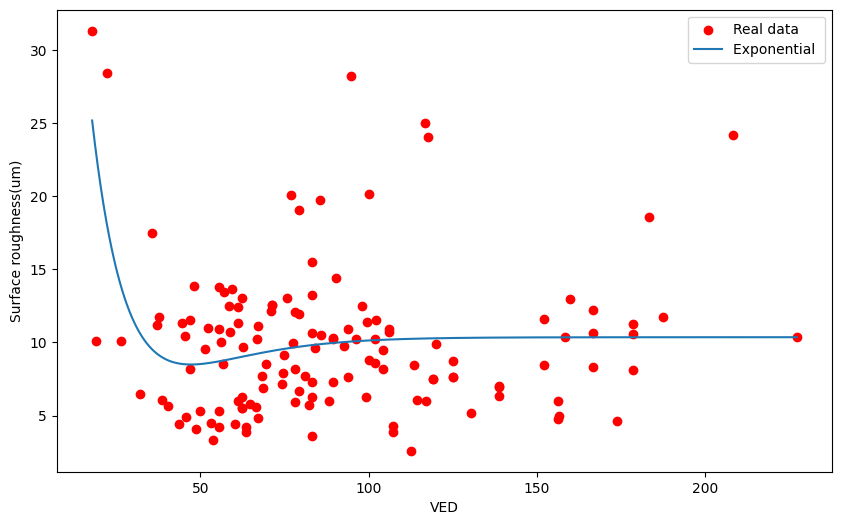

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

VED = data['VED'].values
Ra = data['Ra'].values

VED_norm = normalize(VED)

def exp_model(x, a, b, c, d, e):
    return a * np.exp(-b * x) + c * np.exp(d * x) + e

models = [
    {"name": "Exponential", "func": exp_model, "p0": [-58.91968767,  13.62880511,  74.08045558 ,-16.95740151 , 10.24295125]},
]

x_norm_vals = np.linspace(np.min(VED_norm), np.max(VED_norm), 2000)
x_vals = denormalize(x_norm_vals, VED)

plt.figure(figsize=(10, 6))
plt.scatter(VED, Ra, color="red", label="Real data")

for model in models:
    params, covariance = curve_fit(model["func"], VED_norm, Ra, p0=model["p0"], maxfev=20000)
   
    Ra_pred = model["func"](VED_norm, *params)
    
    mae = mean_absolute_error(Ra, Ra_pred)
    rmse = np.sqrt(mean_squared_error(Ra, Ra_pred))
    
    mape = np.mean(np.abs((Ra - Ra_pred) / Ra)) * 100
    
    print(f"{model['name']} parameters: {params}")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("MAPE:", mape)  
    
    y_fit = model["func"](x_norm_vals, *params)
    
    plt.plot(x_vals, y_fit, label=f"{model['name']} ")

plt.xlabel("VED")
plt.ylabel("Surface roughness(um)")
plt.legend()

plt.show()


In [62]:
Ra_pred = pd.DataFrame(Ra_pred)
Ra_pred['Ra_reel']=Ra


Ra_pred.to_excel("pred.xlsx", index=False)

Optimizing Exponential model...
Best parameters for Exponential: [ 175.17947077   48.19869314 -159.73541745  -50.22904847    9.62214118]


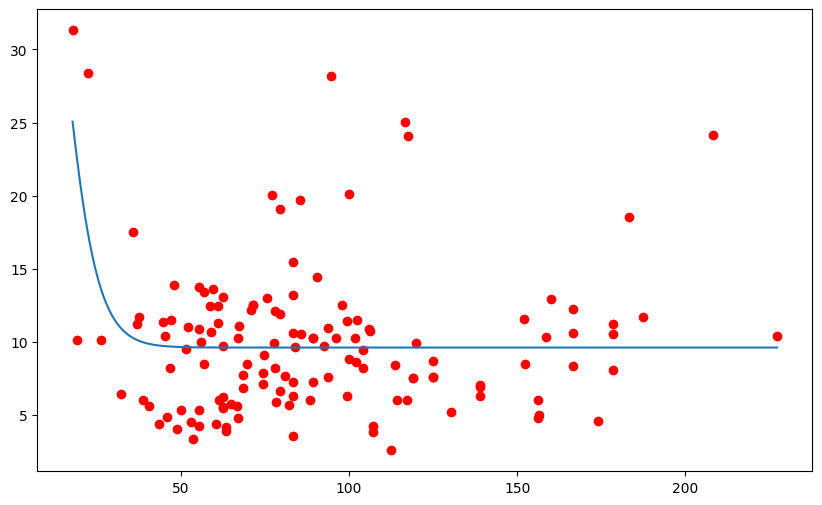

In [63]:
from scipy.optimize import differential_evolution


def objective_function(params, model_func, x_data, y_data):
    y_pred = model_func(x_data, *params)
    mse = np.mean((y_pred - y_data)**2)
    return np.sqrt(mse)

plt.figure(figsize=(10, 6))
plt.scatter(VED, Ra, color="red", label="Real data")
for model in models:
    print(f"Optimizing {model['name']} model...")
    
    
model["name"] == "exp_poly_inv"
bounds = [(-200, 200), (-200, 200), (-200, 200), (-200, 200), (-200, 200)]  
     
    
# Recherche par évolution différentielle
result = differential_evolution(objective_function, bounds, args=(model["func"], VED_norm, Ra), maxiter=1000, popsize=20)

print(f"Best parameters for {model['name']}: {result.x}")

y_fit = model["func"](x_norm_vals, *result.x)

    
plt.plot(x_vals, y_fit, label=f"{model['name']} (Optimized)")

MAE: 4.5500
RMSE: 6.7865


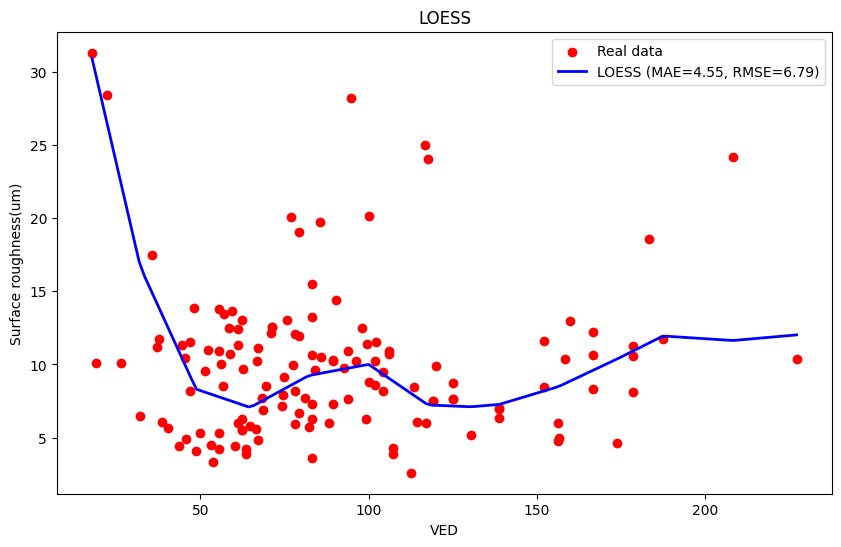

In [69]:
VED = data['VED'].values 
Ra = data['Ra'].values 

VED_norm = normalize(VED)
Ra_norm = normalize(Ra)

lowess = sm.nonparametric.lowess(Ra_norm, VED_norm, frac=0.15, it=10000, delta=0.085) 

x_norm_vals = np.linspace(np.min(VED_norm), np.max(VED_norm), len(Ra))
y_norm_fit = np.interp(x_norm_vals, lowess[:, 0], lowess[:, 1])
y_fit = denormalize(y_norm_fit, Ra)

mae = mean_absolute_error(Ra, y_fit)
rmse = np.sqrt(mean_squared_error(Ra, y_fit))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
plt.figure(figsize=(10, 6))
plt.scatter(VED, Ra, color="red", label="Real data")
plt.plot(denormalize(x_norm_vals, VED), y_fit,label=f"LOESS (MAE={mae:.2f}, RMSE={rmse:.2f})", color="blue", linewidth=2)

plt.xlabel("VED")
plt.ylabel("Surface roughness(um)")
plt.legend()
plt.title("LOESS")
plt.show()


MAPE: 53.1528
Mean Absolute Error (MAE): 4.3635
Root Mean Squared Error (RMSE): 6.0161
Équation approchée : y = 25.2402 x^0 + -134.8756 x^1 + 386.4009 x^2 + -469.1928 x^3 + 207.8170 x^4


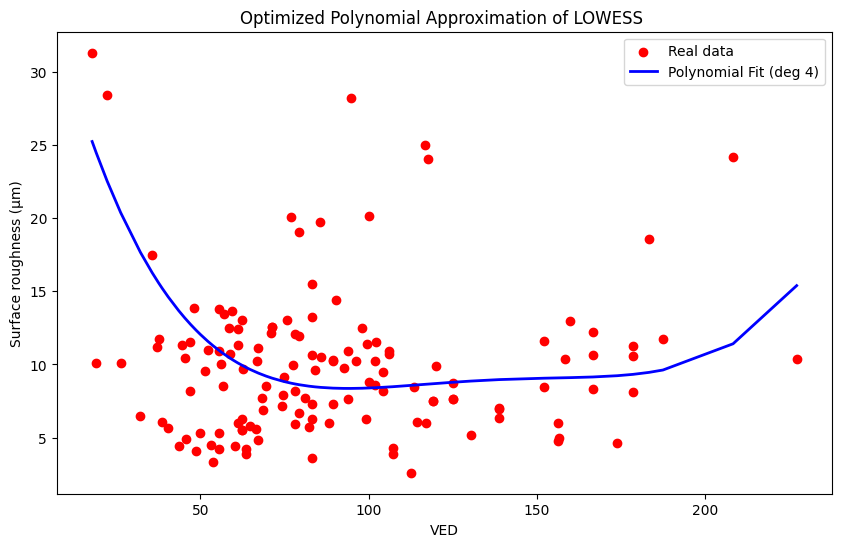

In [70]:


lowess = sm.nonparametric.lowess(Ra, VED_norm, frac=0.095, it=200, delta=0.095)

x_smooth = lowess[:, 0]
y_smooth = lowess[:, 1]

degree = 4
coeffs = np.polyfit(x_smooth, y_smooth, degree)
poly_eq = np.poly1d(coeffs)

y_fit = poly_eq(x_smooth)

mape = np.mean(np.abs((Ra - y_fit) / Ra)) * 100
mae = mean_absolute_error(Ra, y_fit)
rmse = np.sqrt(mean_squared_error(Ra, y_fit))

print(f"MAPE: {mape:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


equation_str = "y = " + " + ".join([f"{c:.4f} x^{i}" for i, c in enumerate(coeffs[::-1])])
print("Équation approchée :", equation_str)


plt.figure(figsize=(10, 6))
plt.scatter(VED, Ra, color="red", label="Real data")
plt.plot(denormalize(x_smooth, VED), y_fit, 
         label=f"Polynomial Fit (deg {degree})", color="blue", linewidth=2)

plt.xlabel("VED")
plt.ylabel("Surface roughness (µm)")
plt.legend()
plt.title("Optimized Polynomial Approximation of LOWESS ")
plt.show()


Équation exponentielle approximée : y = 0.9736 * exp(-15.6259 * x) + 263.5204 * exp(0.0008 * x) + -263.4236
MAPE: 44.6031
Mean Absolute Error (MAE) : 4.0116
Root Mean Squared Error (RMSE) : 6.2428


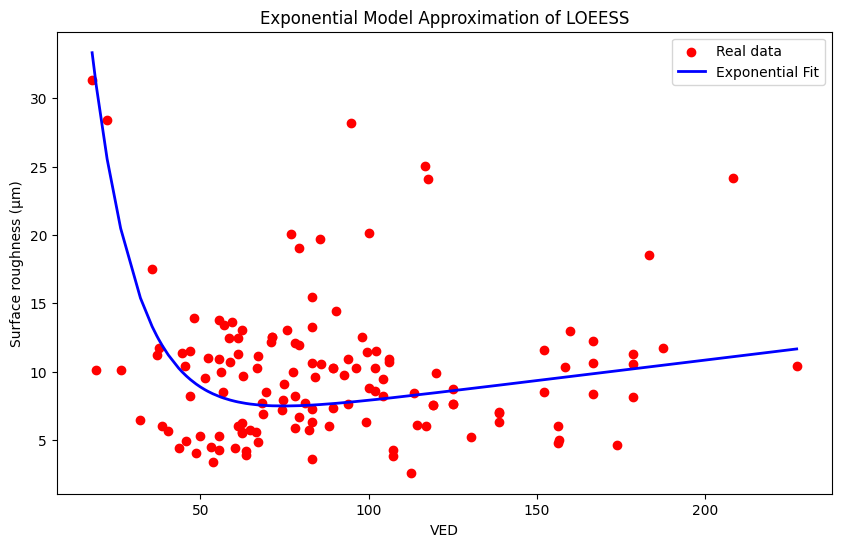

In [71]:

VED = data['VED'].values
Ra = data['Ra'].values

VED_norm = normalize(VED)
Ra_norm = normalize(Ra)

lowess = sm.nonparametric.lowess(Ra_norm, VED_norm, frac=0.1, it=1000, delta=0.085)

x_smooth = lowess[:, 0]  
y_smooth = lowess[:, 1] 

popt, pcov = curve_fit(exp_model, x_smooth, y_smooth, maxfev=100000)

a_opt, b_opt, c_opt, d_opt, e_opt = popt
print(f"Équation exponentielle approximée : y = {a_opt:.4f} * exp(-{b_opt:.4f} * x) + {c_opt:.4f} * exp({d_opt:.4f} * x) + {e_opt:.4f}")

y_exp_fit = exp_model(x_smooth, *popt)
y_fit = denormalize(y_exp_fit, Ra) 
mape = np.mean(np.abs((Ra - y_fit) / Ra)) * 100
mae = mean_absolute_error(Ra, y_fit)
rmse = np.sqrt(mean_squared_error(Ra, y_fit))
print(f"MAPE: {mape:.4f}")
print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(VED, Ra, color="red", label="Real data")
plt.plot(denormalize(x_smooth, VED), y_fit, label="Exponential Fit", color="blue", linewidth=2)

plt.xlabel("VED")
plt.ylabel("Surface roughness (µm)")
plt.legend()
plt.title("Exponential Model Approximation of LOEESS")
plt.show()



🔹 Régression Linéaire
MAE: 3.0882, RMSE: 3.7158, MAPE: 0.3847, R²: 0.1847

🔹 Régression Polynomiale avec Interactions
MAE: 2.7637, RMSE: 3.2632, MAPE: 0.3757, R²: 0.3712
Équation: Ra = 21.5944 + 9.7171 * p + -31.9165 * v + -123.5555 * h + -1057.7118 * t + 140.2435 * p*v + -993.8571 * p*h + -1800.0544 * p*t + 321.0295 * v*h + 2149.0172 * v*t + 16634.5219 * h*t


C:\Users\hrouabah\AppData\Local\Temp\ipykernel_19180\3061877226.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\hrouabah\AppData\Local\Temp\ipykernel_19180\3061877226.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


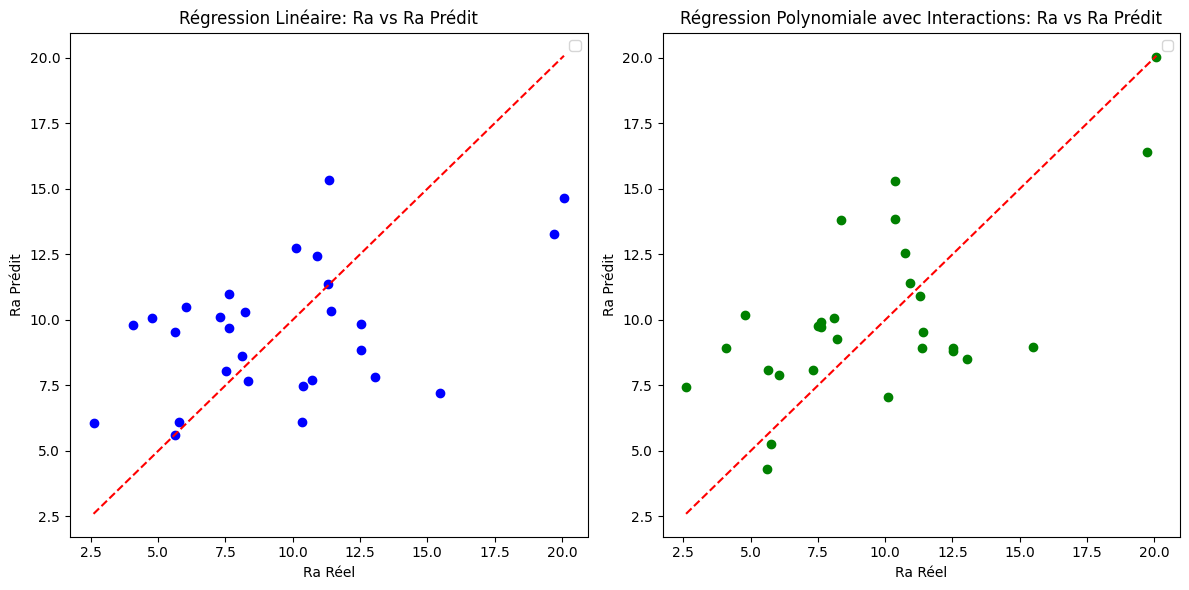

In [72]:



X = data[['p', 'v', 'h', 't']] 
y = data['Ra']  
X = normalize(X)  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)


mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("\n🔹 Régression Linéaire")
print(f"MAE: {mae_linear:.4f}, RMSE: {rmse_linear:.4f}, MAPE: {mape_linear:.4f}, R²: {r2_linear:.4f}")


poly = PolynomialFeatures(degree=3, interaction_only=True)  
poly_model = make_pipeline(poly, LinearRegression())
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)


mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mape_poly = mean_absolute_percentage_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("\n🔹 Régression Polynomiale avec Interactions")
print(f"MAE: {mae_poly:.4f}, RMSE: {rmse_poly:.4f}, MAPE: {mape_poly:.4f}, R²: {r2_poly:.4f}")

coefs_poly = poly_model.named_steps['linearregression'].coef_
intercept_poly = poly_model.named_steps['linearregression'].intercept_
print(f"Équation: Ra = {intercept_poly:.4f} + "
      f"{coefs_poly[1]:.4f} * p + {coefs_poly[2]:.4f} * v + {coefs_poly[3]:.4f} * h + {coefs_poly[4]:.4f} * t + "
      f"{coefs_poly[5]:.4f} * p*v + {coefs_poly[6]:.4f} * p*h + {coefs_poly[7]:.4f} * p*t + "
      f"{coefs_poly[8]:.4f} * v*h + {coefs_poly[9]:.4f} * v*t + {coefs_poly[10]:.4f} * h*t")


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_linear, color='blue', )
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # ligne idéale
plt.title('Régression Linéaire: Ra vs Ra Prédit')
plt.xlabel('Ra Réel')
plt.ylabel('Ra Prédit')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_poly, color='green',)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # ligne idéale
plt.title('Régression Polynomiale avec Interactions: Ra vs Ra Prédit')
plt.xlabel('Ra Réel')
plt.ylabel('Ra Prédit')
plt.legend()

plt.tight_layout()
plt.show()


ANOVA

4 parametre

In [6]:
data_extended = data.copy()

data_extended['I(p^2)'] = data_extended['p']**2
data_extended['I(v^2)'] = data_extended['v']**2
data_extended['I(h^2)'] = data_extended['h']**2
data_extended['I(t^2)'] = data_extended['t']**2


data_extended['p:v'] = data_extended['p'] * data_extended['v']
data_extended['p:h'] = data_extended['p'] * data_extended['h']
data_extended['p:t'] = data_extended['p'] * data_extended['t']
data_extended['v:h'] = data_extended['v'] * data_extended['h']
data_extended['v:t'] = data_extended['v'] * data_extended['t']
data_extended['h:t'] = data_extended['h'] * data_extended['t']
data_extended['p:v:h'] = data_extended['p'] * data_extended['v'] * data_extended['h']
data_extended['p:v:t'] = data_extended['p'] * data_extended['v'] * data_extended['t']
data_extended['p:h:t'] = data_extended['p'] * data_extended['h'] * data_extended['t']
data_extended['v:h:t'] = data_extended['v'] * data_extended['h'] * data_extended['t']
data_extended['p:v:h:t'] = data_extended['p'] * data_extended['v'] * data_extended['h'] * data_extended['t']

variables = ['p', 'v', 'h', 't']

for var1, var2 in combinations(variables, 2):
    data_extended[f'I({var1}^2 * {var2})'] = (data_extended[var1]**2) * data_extended[var2]

for var1, var2, var3 in combinations(variables, 3):
    data_extended[f'I({var1}^2 * {var2} * {var3}^2)'] = (data_extended[var1]**2) * (data_extended[var2]) * (data_extended[var3]**2)

data_extended[f'I(p^2 * v^2 * h^2 * t^2)'] = (data_extended['p']**2) * (data_extended['v']**2) * (data_extended['h']**2) * (data_extended['t']**2)

data_extended['I(p^2 * v * h)'] = (data_extended['p']**2) * data_extended['v'] * (data_extended['h'])
data_extended['I(p * v^2 * h)'] = data_extended['p'] * (data_extended['v']) * (data_extended['h']**2)
data_extended['I(p^2 * v * h * t)'] = (data_extended['p']**2) * data_extended['v'] * data_extended['h'] * (data_extended['t'])


data_extended['I(sqrt(h)'] = np.sqrt(data_extended['h'])
data_extended['I(sqrt(v)'] = np.sqrt(data_extended['v'])
data_extended['I(sqrt(p)'] = np.sqrt(data_extended['p'])
data_extended['I(sqrt(t)'] = np.sqrt(data_extended['t'])

data_extended['I(sqrt(p) * v)'] = np.sqrt(data_extended['p']) * data_extended['v']
data_extended['I(sqrt(p) * h)'] = np.sqrt(data_extended['p']) * data_extended['h']
data_extended['I(sqrt(p) * t)'] = np.sqrt(data_extended['p']) * data_extended['t']

data_extended['I(sqrt(v) * p)'] = np.sqrt(data_extended['v']) * data_extended['p']
data_extended['I(sqrt(v) * h)'] = np.sqrt(data_extended['v']) * data_extended['h']
data_extended['I(sqrt(v) * t)'] = np.sqrt(data_extended['v']) * data_extended['t']

data_extended['I(sqrt(h) * p)'] = np.sqrt(data_extended['h']) * data_extended['p']
data_extended['I(sqrt(h) * v)'] = np.sqrt(data_extended['h']) * data_extended['v']
data_extended['I(sqrt(h) * t)'] = np.sqrt(data_extended['h']) * data_extended['t']

data_extended['I(sqrt(t) * p)'] = np.sqrt(data_extended['t']) * data_extended['p']
data_extended['I(sqrt(t) * v)'] = np.sqrt(data_extended['t']) * data_extended['v']
data_extended['I(sqrt(t) * h)'] = np.sqrt(data_extended['t']) * data_extended['h']

data_extended['I(p * sqrt(v))'] = data_extended['p'] * np.sqrt(data_extended['v'])
data_extended['I(sqrt(h) * t^2)'] = np.sqrt(data_extended['h']) * (data_extended['t']**2)
data_extended['I(p * h * sqrt(t))'] = data_extended['p'] * data_extended['h'] * np.sqrt(data_extended['t'])

data_extended['I(log(p) * v)'] = np.log(data_extended['p'] + 1e-6) * data_extended['v']
data_extended['I(log(p) * t)'] = np.log(data_extended['p'] + 1e-6) * data_extended['t']
data_extended['I(log(p) * h)'] = np.log(data_extended['p'] + 1e-6) * data_extended['h']
data_extended['I(log(v) * p)'] = np.log(data_extended['v'] + 1e-6) * data_extended['p']
data_extended['I(log(v) * h)'] = np.log(data_extended['v'] + 1e-6) * data_extended['h']
data_extended['I(log(v) * t)'] = np.log(data_extended['v'] + 1e-6) * data_extended['t']
data_extended['I(log(h) * p)'] = np.log(data_extended['h'] + 1e-6) * data_extended['p']
data_extended['I(log(h) * v)'] = np.log(data_extended['h'] + 1e-6) * data_extended['v']
data_extended['I(log(h) * t)'] = np.log(data_extended['h'] + 1e-6) * data_extended['t']
data_extended['I(log(t) * p)'] = np.log(data_extended['t'] + 1e-6) * data_extended['p']
data_extended['I(log(t) * h)'] = np.log(data_extended['t'] + 1e-6) * data_extended['h']
data_extended['I(log(t) * v)'] = np.log(data_extended['t'] + 1e-6) * data_extended['v']
for var in variables:
    data_extended[f'I({var}^-1)'] = 1 / (data_extended[var] + 1e-6)


for var1 in variables:
    for var2 in variables:
        if var1 != var2:
            data_extended[f'I({var1} * {var2}^-1)'] = data_extended[var1] / (data_extended[var2] + 1e-6)


for r in range(2, len(variables) + 1):
    for combo in combinations(variables, r):
        
        col_name = 'I(' + ' * '.join([f'{v}^-1' for v in combo]) + ')'
        inv_product = np.ones(len(data_extended))
        for v in combo:
            inv_product *= 1 / (data_extended[v] + 1e-6)
        data_extended[col_name] = inv_product

In [7]:
X = data_extended.drop(columns=['Ra', 'density', 'VED', 'LED', 'PED'], errors='ignore')
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

X_standardized = pd.DataFrame(X_standardized, columns=X.columns)

y = data['Ra']
f_scores, p_values = f_regression(X_standardized, y)
anova_results = pd.DataFrame({'Variable': X_standardized.columns, 'F-Score': f_scores, 'p-value': p_values})
significant_vars = anova_results[anova_results['p-value'] < 0.05]
significant_vars = significant_vars.sort_values(by='F-Score', ascending=False)
print(significant_vars)

                 Variable    F-Score       p-value
24             I(h^2 * t)  44.092705  7.148687e-10
13                    h:t  34.521165  3.165256e-08
48         I(sqrt(t) * h)  28.480137  3.928161e-07
45         I(sqrt(h) * t)  25.394839  1.483222e-06
50       I(sqrt(h) * t^2)  25.042898  1.729314e-06
62          I(log(t) * h)  22.618274  5.036445e-06
78            I(t * v^-1)  20.107553  1.557587e-05
6                  I(h^2)  19.328338  2.221951e-05
60          I(log(h) * t)  19.000652  2.581817e-05
75            I(h * v^-1)  18.116098  3.880107e-05
16                  p:h:t  17.148085  6.082399e-05
7                  I(t^2)  15.221377  1.506551e-04
51     I(p * h * sqrt(t))  15.084054  1.608211e-04
3                       t  14.793879  1.846706e-04
36              I(sqrt(t)  14.186374  2.470059e-04
54          I(log(p) * h)  13.535847  3.379548e-04
68            I(p * v^-1)  13.247526  3.886053e-04
2                       h  13.169941  4.035171e-04
53          I(log(p) * t)  12.6

In [8]:
from sklearn.feature_selection import mutual_info_regression
X = data_extended.drop(columns=['Ra', 'density', 'VED', 'LED', 'PED'], errors='ignore')
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

X_standardized = pd.DataFrame(X_standardized, columns=X.columns)
y = data_extended['Ra']

mi_scores = mutual_info_regression(X_standardized, y)

mi_results = pd.DataFrame({'Variable': X_standardized.columns, 'MI Score': mi_scores})

mi_results = mi_results.sort_values(by='MI Score', ascending=False)

print("\nScores d'Information Mutuelle :")
print(mi_results)

top_features = mi_results.head(10)['Variable']
print("\nTop 10 des variables les plus significatives selon l'information mutuelle :")
print(top_features)

X_selected = X[top_features]



Scores d'Information Mutuelle :
                 Variable  MI Score
53          I(log(p) * t)  0.327747
89  I(v^-1 * h^-1 * t^-1)  0.307899
14                  p:v:h  0.277176
17                  v:h:t  0.272724
30         I(p^2 * v * h)  0.263358
..                    ...       ...
80         I(p^-1 * v^-1)  0.021602
84         I(v^-1 * t^-1)  0.021287
74            I(h * p^-1)  0.019265
44         I(sqrt(h) * v)  0.005895
72            I(v * h^-1)  0.000000

[91 rows x 2 columns]

Top 10 des variables les plus significatives selon l'information mutuelle :
53            I(log(p) * t)
89    I(v^-1 * h^-1 * t^-1)
14                    p:v:h
17                    v:h:t
30           I(p^2 * v * h)
57            I(log(v) * t)
43           I(sqrt(h) * p)
31           I(p * v^2 * h)
60            I(log(h) * t)
39           I(sqrt(p) * t)
Name: Variable, dtype: object


In [9]:
from sklearn.feature_selection import f_regression, mutual_info_regression

X = data_extended.drop(columns=['Ra', 'density', 'VED', 'LED', 'PED'], errors='ignore')

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
X_standardized = pd.DataFrame(X_standardized, columns=X.columns)
y = data['Ra']

f_scores, p_values = f_regression(X_standardized, y)
anova_results = pd.DataFrame({
    'Variable': X_standardized.columns,
    'F-Score': f_scores,
    'p-value': p_values
})

anova_significant = anova_results[anova_results['p-value'] < 0.05]['Variable'].tolist()

mi_scores = mutual_info_regression(X_standardized, y)
mi_results = pd.DataFrame({
    'Variable': X_standardized.columns,
    'MI-Score': mi_scores
})

threshold = 0.1
mi_significant = mi_results[mi_results['MI-Score'] > threshold]['Variable'].tolist()

selected_vars = list(set(anova_significant) & set(mi_significant))

X_selected_vars = X[selected_vars]

print("Variables sélectionnées (communes entre ANOVA et Information Mutuelle) :")
print(selected_vars)


Variables sélectionnées (communes entre ANOVA et Information Mutuelle) :
['p', 'I(log(v) * t)', 'I(p^2 * t)', 'I(t^-1)', 'h:t', 'I(sqrt(p) * t)', 'p:h:t', 'I(sqrt(h) * t)', 'I(log(h) * t)', 'I(p * h * sqrt(t))', 'I(v^-1)', 'I(v * p^-1)', 'I(t * p^-1)', 'v:h:t', 'I(t^2)', 'I(sqrt(h) * t^2)', 'p:h', 'I(sqrt(t)', 'I(p^2 * h)', 'I(log(p) * h)', 'I(sqrt(t) * p)', 'I(p^2 * v * h^2)', 'I(p * v^-1)', 'I(log(t) * p)', 't', 'I(p^2 * h * t^2)', 'I(h^-1 * t^-1)', 'I(sqrt(p) * h)', 'I(p^-1 * t^-1)', 'p:t', 'I(v * t^-1)', 'I(log(p) * t)', 'I(t * v^-1)', 'I(p^2)', 'I(sqrt(h) * p)', 'I(log(h) * p)', 'I(p^-1 * h^-1 * t^-1)']


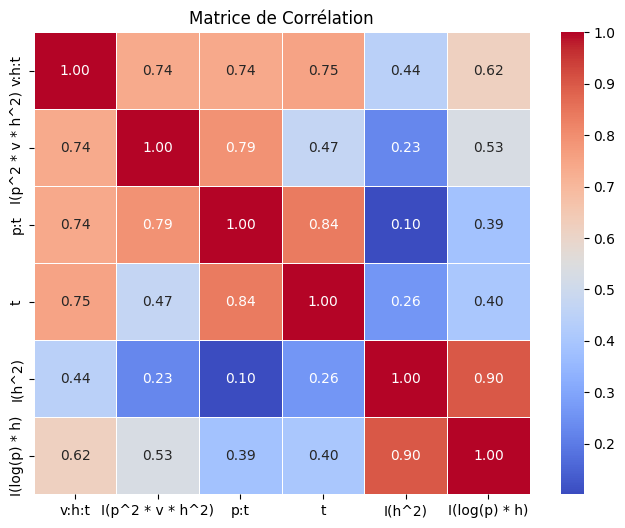

In [78]:
plt.figure(figsize=(8, 6))
corr_matrix = X_filtered.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Matrice de Corrélation")

plt.show()

In [12]:
corr_matrix = X_selected_vars.corr().abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]

X_filtered = X_selected_vars.drop(columns=to_drop)

print(f"Variables supprimées car trop corrélées: {to_drop}")
print(f"Nombre de variables restantes: {X_filtered.shape[1]}")

Variables supprimées car trop corrélées: ['I(p^2 * t)', 'I(t^-1)', 'I(sqrt(p) * t)', 'p:h:t', 'I(sqrt(h) * t)', 'I(log(h) * t)', 'I(p * h * sqrt(t))', 'v:h:t', 'I(t^2)', 'I(sqrt(h) * t^2)', 'p:h', 'I(sqrt(t)', 'I(p^2 * h)', 'I(sqrt(t) * p)', 'I(p^2 * v * h^2)', 'I(log(t) * p)', 't', 'I(p^2 * h * t^2)', 'I(h^-1 * t^-1)', 'I(sqrt(p) * h)', 'I(p^-1 * t^-1)', 'p:t', 'I(log(p) * t)', 'I(t * v^-1)', 'I(p^2)', 'I(sqrt(h) * p)', 'I(log(h) * p)', 'I(p^-1 * h^-1 * t^-1)']
Nombre de variables restantes: 9


In [13]:
X_filtered

,p,I(log(v) * t),h:t,I(v^-1),I(v * p^-1),I(t * p^-1),I(log(p) * h),I(p * v^-1),I(v * t^-1)
0,150.0,149.786614,2875.0,0.002500,2.666667,0.166667,576.223060,0.375000,15.999999
1,150.0,163.777008,2875.0,0.001429,4.666667,0.166667,576.223060,0.214286,27.999999
2,150.0,172.693882,2875.0,0.001000,6.666667,0.166667,576.223060,0.150000,39.999998
3,180.0,149.786614,2875.0,0.002500,2.222222,0.138889,597.190038,0.450000,15.999999
4,180.0,163.777008,2875.0,0.001429,3.888889,0.138889,597.190038,0.257143,27.999999
...,...,...,...,...,...,...,...,...,...
131,360.0,340.119738,4000.0,0.001111,2.500000,0.138889,470.888323,0.400000,18.000000
132,107.0,179.743936,6000.0,0.002500,3.738318,0.280374,934.565769,0.267500,13.333333
133,107.0,359.487873,12000.0,0.002500,3.738318,0.560748,934.565769,0.267500,6.666667
134,107.0,186.438243,6000.0,0.002000,4.672897,0.280374,934.565769,0.214000,16.666666


MAE : 3.192403785015472
RMSE : 4.164922988327516
MAPE : 37.61121578850841%
R² : 0.010985894931822227


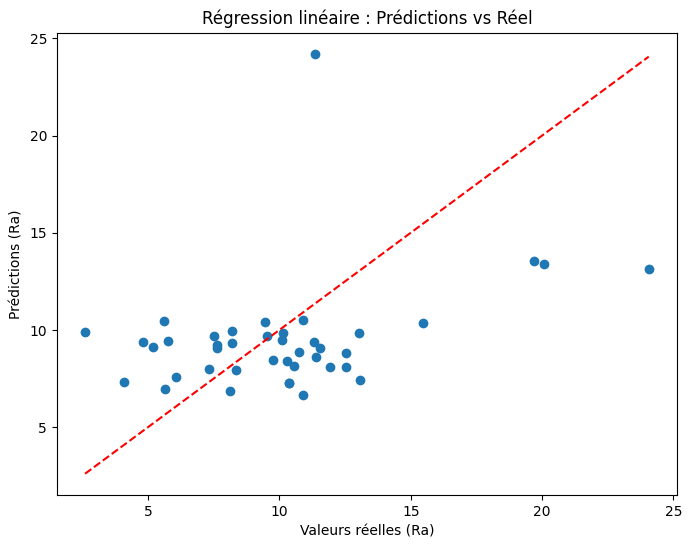

In [80]:
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X_filtered)
X_standardized = pd.DataFrame(X_standardized, columns=X_filtered.columns)

y = data['Ra'].values  
  

X_train, X_test, y_train, y_test = train_test_split(X_standardized, y, test_size=0.30, random_state=42,)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)  
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print(f'MAE : {mae}')
print(f'RMSE : {rmse}')
print(f'MAPE : {mape}%')
print(f'R² : {r2}')



plt.figure(figsize=(8, 6))
plt.scatter(y_test,y_pred )
plt.xlabel("Valeurs réelles (Ra)")
plt.ylabel("Prédictions (Ra)")
plt.title("Régression linéaire : Prédictions vs Réel")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Ligne y=x
plt.show()


In [88]:

from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print("mae",mae)

print(f"RMSE: {rmse}")
print(f'R²: {r2:.4f}')


mae 1.9816121951219452
RMSE: 2.7634055906241164
R²: 0.5646


In [89]:
X = data.iloc[:,:4]
y = data_extended['Ra']
X=normalize(X)
poly_interaction = PolynomialFeatures(degree=3, interaction_only=True)
X_interaction = poly_interaction.fit_transform(X)
X_interaction=normalize(X_interaction) 
X_train, X_test, y_train, y_test = train_test_split(X_interaction, y, test_size=0.2, random_state=42)

model_interaction = LinearRegression()

model_interaction.fit(X_train, y_train)

y_pred_interaction = model_interaction.predict(X_test)

r2 = r2_score(y_test, y_pred_interaction)
mse = mean_squared_error(y_test, y_pred_interaction)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_interaction))
print("mae",mae)

print(f"RMSE: {rmse}")
print(f'R²: {r2:.4f}')

print(f"Coefficients: {model_interaction.coef_}")
print(f"Intercept : {model_interaction.intercept_}")


mae 1.9816121951219452
RMSE: 3.2632040223032237
R²: 0.3712
Coefficients: [ 0.00000000e+00  9.71712511e+00 -3.19164851e+01 -1.23555473e+02
 -1.05771181e+03  1.40243544e+02 -9.93857124e+02 -1.80005437e+03
  3.21029533e+02  2.14901718e+03  1.66345219e+04 -4.09878391e+02
 -4.28526099e+03  7.58946651e+04 -3.40104219e+04]
Intercept : 21.594435237517786


In [90]:

from gplearn.genetic import SymbolicRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler


X = data[['p', 'v', 'h', 't']] 
y = data['Ra']
X=normalize(X)

log_transformer = FunctionTransformer(np.log1p, validate=True)
log_model = make_pipeline(log_transformer, LinearRegression())
log_model.fit(X, y)
y_pred_log = log_model.predict(X)


mae_log = mean_absolute_error(y, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y, y_pred_log))
r2_log = r2_score(y, y_pred_log)

print("\n🔹 Régression Logarithmique")
print(f"MAE: {mae_log:.4f}, RMSE: {rmse_log:.4f}, R²: {r2_log:.4f}")

coefs = log_model.named_steps['linearregression'].coef_
intercept = log_model.named_steps['linearregression'].intercept_
print(f"Equation: Ra = {intercept:.4f} + {coefs[0]:.4f} * log(p) + {coefs[1]:.4f} * log(v) + {coefs[2]:.4f} * log(h) + {coefs[3]:.4f} * log(t)")





🔹 Régression Logarithmique
MAE: 3.4086, RMSE: 4.6405, R²: 0.1756
Equation: Ra = 8.3384 + 10.2347 * log(p) + -8.3807 * log(v) + 52.2906 * log(h) + 102.3928 * log(t)


In [ ]:
def box_cox_fun(data):

    lambda_val = 0.5

    data, _ = boxcox(data + 1e-5)
    return data,lambda_val
def inverse_box_cox(data, lambda_val=0.5):
    if lambda_val == 0:
        return np.exp(data)
    else:
        return (data * lambda_val + 1) ** (1 / lambda_val) - 1e-5

data=pd.read_excel("data - copie.xlsx")
data.columns=['p','v','h','t','Ra','density','VED','LED','PED']
X = data[['p', 'v', 'h', 't']] 
y = data['Ra']
scaler=RobustScaler()
X_scaled =scaler.fit_transform(X)
y_bc=box_cox_fun(Y)


symbolic_model = SymbolicRegressor(
    function_set=('add', 'sub', 'mul', 'div', 'sqrt', 'log'),
    generations=3000, 
    population_size=600,  
    parsimony_coefficient=0.001, 
    max_samples=0.9,
    verbose=1,
    random_state=42
)

symbolic_model.fit(X_scaled, y_bc)
y_pred_symbolic_bc = symbolic_model.predict(X_scaled)
y_pred_symbolic=inverse_boc_cox(y_pred_symbolic_bc)

mae_symb = mean_absolute_error(y, y_pred_symbolic)
rmse_symb = np.sqrt(mean_squared_error(y, y_pred_symbolic))
mape_sy=np.mean(np.abs((y - y_pred_symbolic) / y)) * 100
r2_symb = r2_score(y, y_pred_symbolic)

print("\n🔹 Symbolic regression ")
print(f"MAE: {mae_symb:.4f}, RMSE: {rmse_symb:.4f}, R²: {r2_symb:.4f}")
print("Equation Symbolique:", symbolic_model._program)

plt.figure(figsize=(12, 5))
plt.scatter(y, y_pred_log, label="Log regression", alpha=0.7)
plt.scatter(y, y_pred_symbolic, label="Symbolic regression", alpha=0.7, color='red')
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', lw=2)  
plt.xlabel("Ra")
plt.ylabel("Re predit")
plt.legend()

c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    15.56          18.5191       70          4.78614          3.97901     14.96m
   1    23.86          11.9943       11          3.44386          3.03131     15.75m
   2    43.39          15.0983       11          3.28442          4.42066     18.24m
   3    39.78          9.12423       11          3.19493          5.20055     17.69m
   4    33.05          8.30177       11          3.17604          5.36517     17.61m
   5    19.98          12.5431       11          3.13644          5.71022     17.41m
   6    15.92           11.779       11          3.03239            6.617     14.59m
   7    14.92           16.349       19          3.07738          6.56764     14.95m
   8    15.41          17.7541       11          3.10118          6.01747  

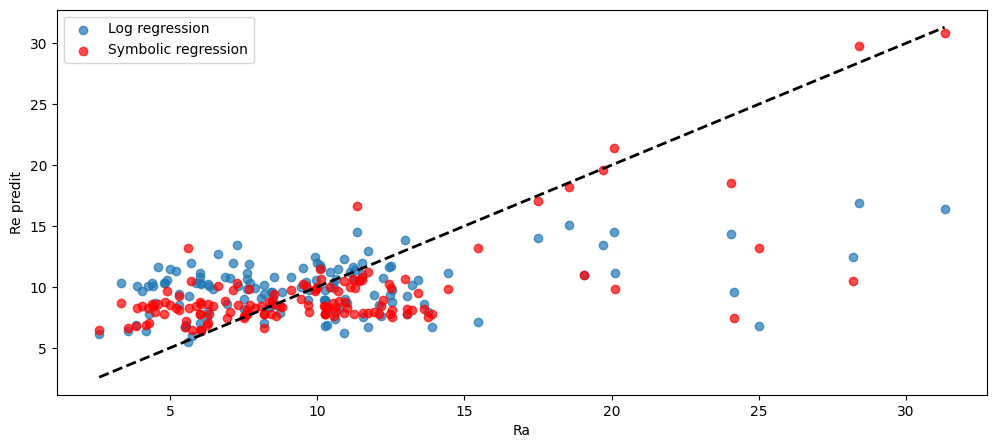

In [52]:
from gplearn.genetic import SymbolicRegressor
symbolic_model = SymbolicRegressor(
    function_set=('add', 'sub', 'mul', 'div', 'sqrt', 'log'),
    generations=3000, 
    population_size=600,  
    parsimony_coefficient=0.001, 
    max_samples=0.9,
    verbose=1,
    random_state=42
)

symbolic_model.fit(X, y)
y_pred_symbolic = symbolic_model.predict(X)


mae_symb = mean_absolute_error(y, y_pred_symbolic)
rmse_symb = np.sqrt(mean_squared_error(y, y_pred_symbolic))
mape_sy=np.mean(np.abs((y - y_pred_symbolic) / y)) * 100
r2_symb = r2_score(y, y_pred_symbolic)

print("\n🔹 Symbolic regression ")
print(f"MAE: {mae_symb:.4f}, RMSE: {rmse_symb:.4f}, R²: {r2_symb:.4f}")
print("Equation Symbolique:", symbolic_model._program)

plt.figure(figsize=(12, 5))
plt.scatter(y, y_pred_log, label="Log regression", alpha=0.7)
plt.scatter(y, y_pred_symbolic, label="Symbolic regression", alpha=0.7, color='red')
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', lw=2)  
plt.xlabel("Ra")
plt.ylabel("Re predit")
plt.legend()

plt.show()